# 📊 Notebook 01 — Data Acquisition & Exploration

**Multimodal RCA Engine — Phase 1: Log Extraction & Processing**

This notebook covers:
1. Automated download of LogHub datasets (HDFS, BGL, OpenStack)
2. Initial data exploration and statistics
3. Log format comparison across datasets
4. Exploratory Data Analysis (EDA) with visualizations

---

## 1.1 — Setup & Imports

In [3]:
import sys
import os
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime

from src.utils import (
    ensure_directories,
    load_config,
    download_and_extract_dataset,
    get_dataset_files,
    get_dataset_dir,
    read_log_file,
    get_file_size_mb,
    count_lines,
    print_section,
    RAW_DIR,
    FIGURES_DIR,
)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Create directories
ensure_directories()

print("✅ Setup complete!")
print(f"📁 Project root: {PROJECT_ROOT}")
print(f"📁 Raw data dir: {RAW_DIR}")

✅ All directories created successfully.
✅ Setup complete!
📁 Project root: d:\multimodal-rca-engine
📁 Raw data dir: d:\multimodal-rca-engine\data\raw


## 1.2 — Load Dataset Configuration

In [4]:
config = load_config()

print_section("LogHub Datasets")
for key, info in config['loghub']['datasets'].items():
    print(f"  📦 {info['name']}")
    print(f"     Description: {info['description']}")
    print(f"     Size: {info['size']}")
    print(f"     Labels: {'✅' if info['labels'] else '❌'}")
    print(f"     Priority: {info['priority']}")
    print()


════════════════════════════════════════════════════════════
  LogHub Datasets
════════════════════════════════════════════════════════════

  📦 HDFS_v1
     Description: Hadoop Distributed File System logs with anomaly labels
     Size: ~1.5GB
     Labels: ✅
     Priority: 1

  📦 BGL
     Description: Blue Gene/L supercomputer logs with alert labels
     Size: ~700MB
     Labels: ✅
     Priority: 2

  📦 OpenStack
     Description: OpenStack cloud platform logs
     Size: ~60MB
     Labels: ✅
     Priority: 3



## 1.3 — Download Datasets

We download from [Zenodo](https://zenodo.org/records/8196385) (hosted by LogHub).

> ⚠️ **Note**: HDFS_v1 is ~1.5GB, BGL is ~700MB. Download may take several minutes.

In [5]:
# Download HDFS_v1 (Primary dataset — has anomaly labels)
print_section("Downloading HDFS_v1")
hdfs_dir = download_and_extract_dataset('hdfs_v1', config)
print(f"📁 HDFS extracted to: {hdfs_dir}")


════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════

⏭️  File already exists: HDFS_v1.zip
⏭️  Already extracted: HDFS_v1 (flat in raw/)
📁 HDFS extracted to: d:\multimodal-rca-engine\data\raw


In [6]:
# Download BGL (Secondary dataset)
print_section("Downloading BGL")
bgl_dir = download_and_extract_dataset('bgl', config)
print(f"📁 BGL extracted to: {bgl_dir}")


════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════

⏭️  File already exists: BGL.zip
⏭️  Already extracted: BGL (flat in raw/)
📁 BGL extracted to: d:\multimodal-rca-engine\data\raw


In [7]:
# Download OpenStack (Tertiary — small, cloud-related)
print_section("Downloading OpenStack")
openstack_dir = download_and_extract_dataset('openstack', config)
print(f"📁 OpenStack extracted to: {openstack_dir}")


════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════

⏭️  File already exists: OpenStack.tar.gz
⏭️  Already extracted: OpenStack (flat in raw/)
📁 OpenStack extracted to: d:\multimodal-rca-engine\data\raw


## 1.4 — Explore Downloaded Files

The archives extract files **flat** into `data/raw/` (no subdirectories).
We use `get_dataset_files()` to locate files for each dataset.

In [8]:
def explore_dataset(dataset_key, name):
    """List all files belonging to a dataset with sizes."""
    print_section(f"Files for {name}")
    
    files = get_dataset_files(dataset_key)
    if not files:
        print(f"  ❌ No files found for {name}. Run download first.")
        return files
    
    for category, file_list in files.items():
        for f in file_list:
            size_mb = get_file_size_mb(f)
            print(f"  📄 [{category:>11s}] {f.name:<40s} {size_mb:>10.2f} MB")
    
    # Also list all files in raw dir for context
    data_dir = get_dataset_dir(dataset_key)
    print(f"\n  📁 Data directory: {data_dir}")
    
    return files

hdfs_files = explore_dataset('hdfs_v1', "HDFS_v1")
bgl_files = explore_dataset('bgl', "BGL")
openstack_files = explore_dataset('openstack', "OpenStack")


════════════════════════════════════════════════════════════
  Files for HDFS_v1
════════════════════════════════════════════════════════════

  📄 [  log_files] HDFS.log                                    1504.88 MB
  📄 [label_files] anomaly_label.csv                             17.77 MB
  📄 [label_files] anomaly_labels.txt                             0.00 MB

  📁 Data directory: d:\multimodal-rca-engine\data\raw

════════════════════════════════════════════════════════════
  Files for BGL
════════════════════════════════════════════════════════════

  📄 [  log_files] BGL.log                                      708.76 MB

  📁 Data directory: d:\multimodal-rca-engine\data\raw

════════════════════════════════════════════════════════════
  Files for OpenStack
════════════════════════════════════════════════════════════

  📄 [  log_files] openstack_abnormal.log                         5.18 MB
  📄 [  log_files] openstack_normal1.log                         14.78 MB
  📄 [  log_files] open

## 1.5 — Preview Raw Log Samples

Let's look at the first few lines of each log file to understand their format.

In [9]:
def preview_dataset_logs(dataset_key, name, n_lines=10):
    """Preview the first N lines of a dataset's log files."""
    files = get_dataset_files(dataset_key)
    if not files or not files.get('log_files'):
        print(f"  ❌ No log files found for {name}")
        return
    
    for lf in files['log_files'][:3]:  # Show max 3 files
        print_section(f"{name} — {lf.name}")
        lines = read_log_file(lf, max_lines=n_lines)
        for i, line in enumerate(lines):
            print(f"  [{i+1:3d}] {line[:150]}")
        
        total = count_lines(lf)
        size = get_file_size_mb(lf)
        print(f"\n  📊 Total lines: {total:,} | Size: {size:.2f} MB")

preview_dataset_logs('hdfs_v1', "HDFS")


════════════════════════════════════════════════════════════
  HDFS — HDFS.log
════════════════════════════════════════════════════════════

  [  1] 081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010
  [  2] 081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-160899968791986
  [  3] 081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010
  [  4] 081109 203519 145 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.14.224:42420 dest: /10.250.14.224:50010
  [  5] 081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_-1608999687919862906 terminating
  [  6] 081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-1608999687919862906 terminatin

In [10]:
preview_dataset_logs('bgl', "BGL")


════════════════════════════════════════════════════════════
  BGL — BGL.log
════════════════════════════════════════════════════════════

  [  1] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.363779 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected
  [  2] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.527847 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected
  [  3] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.675872 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected
  [  4] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.823719 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected
  [  5] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.982731 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected
  [  6] - 1117838571 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.51.131467 R

In [11]:
preview_dataset_logs('openstack', "OpenStack")


════════════════════════════════════════════════════════════
  OpenStack — openstack_abnormal.log
════════════════════════════════════════════════════════════

  [  1] nova-api.log.2017-05-14_21:27:04 2017-05-14 19:39:01.445 25746 INFO nova.osapi_compute.wsgi.server [req-5a2050e7-b381-4ae9-92d2-8b08e9f9f4c0 113d3a99c
  [  2] nova-api.log.2017-05-14_21:27:04 2017-05-14 19:39:01.650 25746 INFO nova.osapi_compute.wsgi.server [req-c26a7d54-55ab-412e-947f-421a2cb934fc 113d3a99c
  [  3] nova-compute.log.2017-05-14_21:27:09 2017-05-14 19:39:02.007 2931 INFO nova.virt.libvirt.driver [req-e285b551-587f-4c1d-8eba-dceb2673637f 113d3a99c3da
  [  4] nova-api.log.2017-05-14_21:27:04 2017-05-14 19:39:02.924 25746 INFO nova.osapi_compute.wsgi.server [req-eb681812-78ae-4a9f-9e2a-96e505285512 113d3a99c
  [  5] nova-compute.log.2017-05-14_21:27:09 2017-05-14 19:39:03.166 2931 INFO nova.compute.manager [-] [instance: 2b590f10-49fd-4ec9-ae41-19596c2f4b25] VM St
  [  6] nova-api.log.2017-05-14_21:27:04 201

## 1.6 — Basic Statistics & Format Comparison

In [12]:
import re

def quick_log_stats(dataset_key, name, sample_size=50000):
    """Compute quick statistics from a sample of logs."""
    files = get_dataset_files(dataset_key)
    if not files or not files.get('log_files'):
        print(f"  ❌ No log files found for {name}")
        return None
    
    # Use the largest log file
    main_file = max(files['log_files'], key=lambda f: f.stat().st_size)
    
    lines = read_log_file(main_file, max_lines=sample_size)
    
    # Count log levels
    level_pattern = re.compile(r'\b(INFO|WARN|WARNING|ERROR|FATAL|DEBUG|TRACE|CRITICAL)\b', re.IGNORECASE)
    levels = Counter()
    for line in lines:
        match = level_pattern.search(line)
        if match:
            levels[match.group(1).upper()] += 1
    
    # Average line length
    avg_len = np.mean([len(l) for l in lines]) if lines else 0
    
    stats = {
        'dataset': name,
        'main_file': main_file.name,
        'sample_size': len(lines),
        'total_lines': count_lines(main_file),
        'file_size_mb': get_file_size_mb(main_file),
        'avg_line_length': avg_len,
        'log_levels': dict(levels),
    }
    
    return stats

print_section("Computing Statistics...")
stats_hdfs = quick_log_stats('hdfs_v1', "HDFS")
stats_bgl = quick_log_stats('bgl', "BGL")
stats_openstack = quick_log_stats('openstack', "OpenStack")

all_stats = [s for s in [stats_hdfs, stats_bgl, stats_openstack] if s is not None]

# Display comparison table
comparison = pd.DataFrame([{
    'Dataset': s['dataset'],
    'Main File': s['main_file'],
    'Total Lines': f"{s['total_lines']:,}",
    'File Size (MB)': f"{s['file_size_mb']:.1f}",
    'Avg Line Length': f"{s['avg_line_length']:.0f}",
    'Log Levels Found': ', '.join(f"{k}:{v}" for k, v in sorted(s['log_levels'].items(), key=lambda x: -x[1])[:5]),
} for s in all_stats])

comparison


════════════════════════════════════════════════════════════
  Computing Statistics...
════════════════════════════════════════════════════════════



,Dataset,Main File,Total Lines,File Size (MB),Avg Line Length,Log Levels Found
0,HDFS,HDFS.log,"11,175,629",1504.9,139,INFO:50000
1,BGL,BGL.log,"4,747,963",708.8,135,"INFO:46797, FATAL:3203"
2,OpenStack,openstack_normal2.log,"137,074",38.6,295,"INFO:49103, WARNING:801, ERROR:96"


## 1.7 — EDA Visualizations

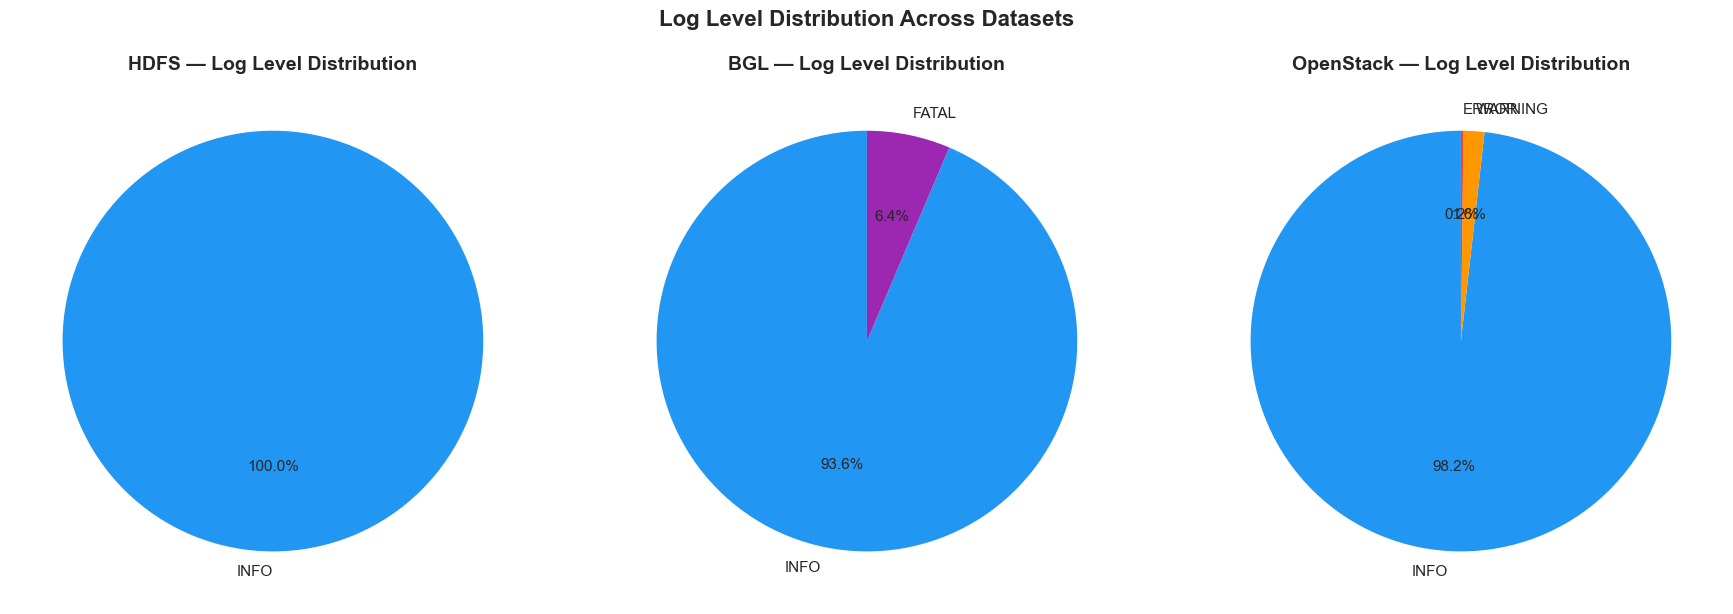

💾 Saved: results/figures/01_log_level_distribution.png


In [13]:
# === Log Level Distribution (Pie Charts) ===

if not all_stats:
    print("⚠️ No stats available — skipping visualization.")
else:
    fig, axes = plt.subplots(1, len(all_stats), figsize=(6 * len(all_stats), 6))
    if len(all_stats) == 1:
        axes = [axes]

    colors = {
        'INFO': '#2196F3',
        'WARN': '#FF9800', 'WARNING': '#FF9800',
        'ERROR': '#F44336',
        'FATAL': '#9C27B0',
        'DEBUG': '#4CAF50',
        'TRACE': '#607D8B',
        'CRITICAL': '#E91E63',
    }

    for ax, s in zip(axes, all_stats):
        levels = s['log_levels']
        if levels:
            labels = list(levels.keys())
            values = list(levels.values())
            pie_colors = [colors.get(l, '#9E9E9E') for l in labels]
            
            wedges, texts, autotexts = ax.pie(
                values, labels=labels, colors=pie_colors,
                autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 11}
            )
            ax.set_title(f"{s['dataset']} — Log Level Distribution", fontsize=14, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'No levels found', ha='center', va='center')
            ax.set_title(f"{s['dataset']}")

    plt.suptitle('Log Level Distribution Across Datasets', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '01_log_level_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Saved: results/figures/01_log_level_distribution.png")

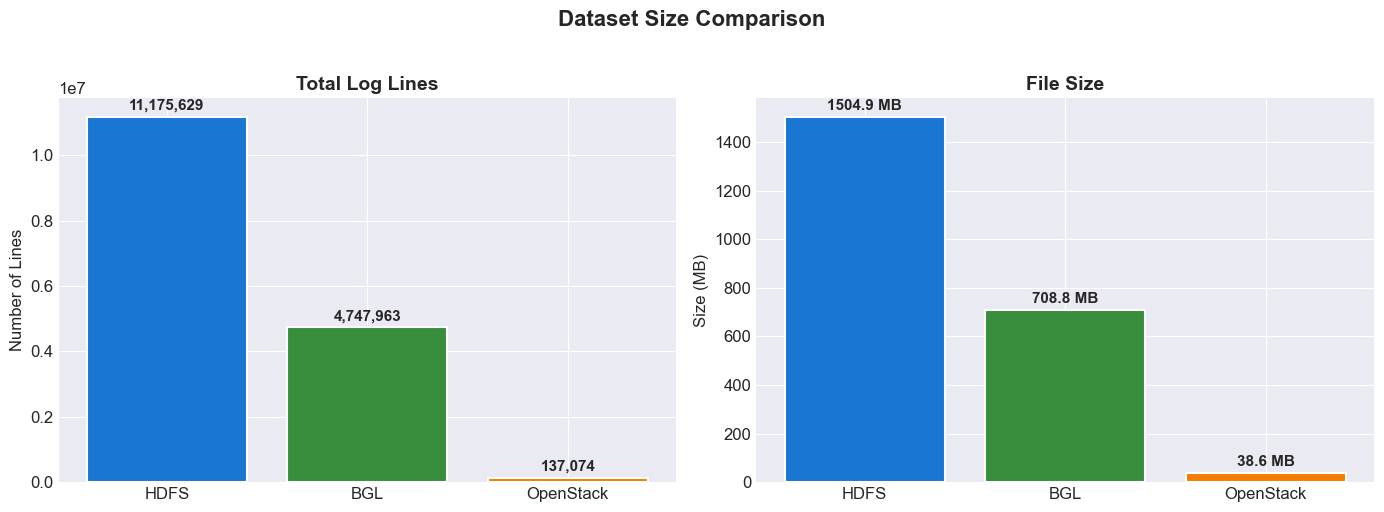

In [14]:
# === Dataset Size Comparison (Bar Chart) ===

if all_stats:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    dataset_names = [s['dataset'] for s in all_stats]
    total_lines = [s['total_lines'] for s in all_stats]
    file_sizes = [s['file_size_mb'] for s in all_stats]

    bar_colors = ['#1976D2', '#388E3C', '#F57C00']

    # Total lines
    bars1 = ax1.bar(dataset_names, total_lines, color=bar_colors[:len(all_stats)], edgecolor='white', linewidth=1.5)
    ax1.set_ylabel('Number of Lines', fontsize=12)
    ax1.set_title('Total Log Lines', fontsize=14, fontweight='bold')
    for bar, val in zip(bars1, total_lines):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(total_lines)*0.01,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # File sizes
    bars2 = ax2.bar(dataset_names, file_sizes, color=bar_colors[:len(all_stats)], edgecolor='white', linewidth=1.5)
    ax2.set_ylabel('Size (MB)', fontsize=12)
    ax2.set_title('File Size', fontsize=14, fontweight='bold')
    for bar, val in zip(bars2, file_sizes):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(file_sizes)*0.01,
                 f'{val:.1f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.suptitle('Dataset Size Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '01_dataset_size_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

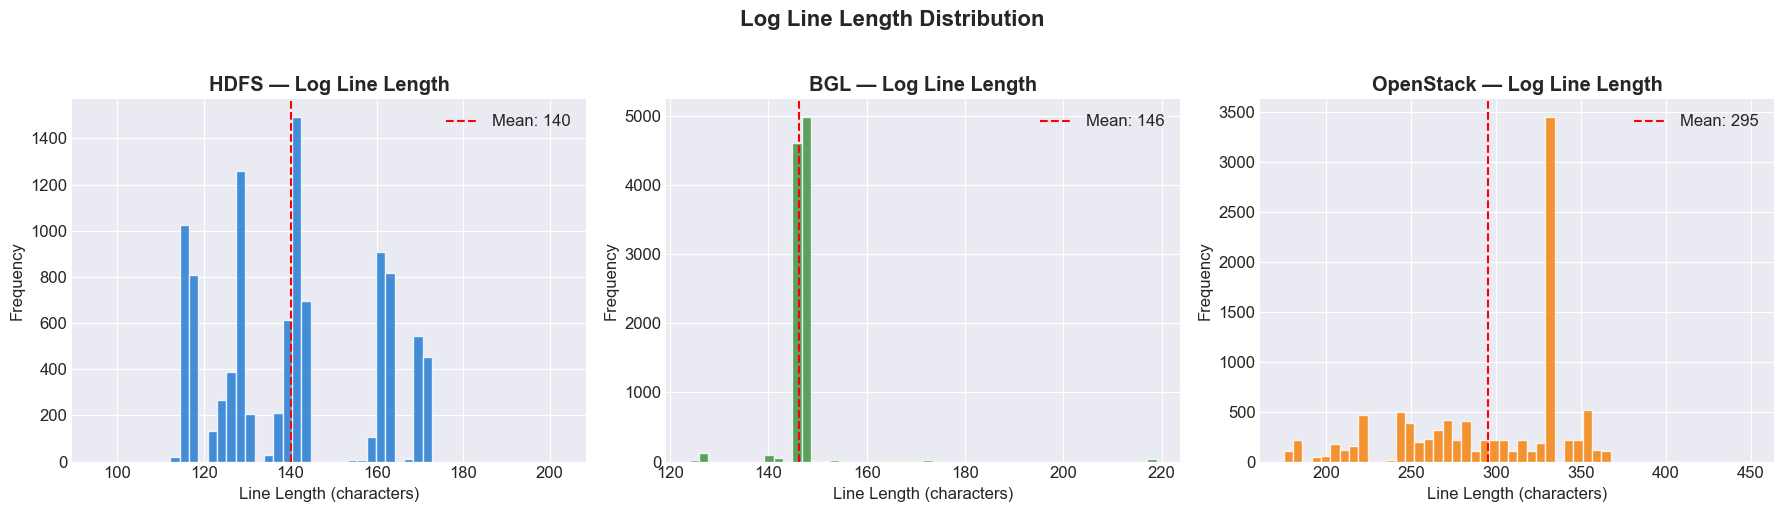

In [15]:
# === Line Length Distribution (Histograms) ===

if all_stats:
    fig, axes = plt.subplots(1, len(all_stats), figsize=(6 * len(all_stats), 5))
    if len(all_stats) == 1:
        axes = [axes]

    dataset_keys_map = {'HDFS': 'hdfs_v1', 'BGL': 'bgl', 'OpenStack': 'openstack'}

    for ax, s in zip(axes, all_stats):
        dk = dataset_keys_map.get(s['dataset'])
        if dk:
            files = get_dataset_files(dk)
            if files and files.get('log_files'):
                main_file = max(files['log_files'], key=lambda f: f.stat().st_size)
                sample = read_log_file(main_file, max_lines=10000)
                lengths = [len(l) for l in sample]
                
                ax.hist(lengths, bins=50, color=bar_colors[all_stats.index(s) % len(bar_colors)], 
                        alpha=0.8, edgecolor='white')
                ax.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
                ax.set_xlabel('Line Length (characters)')
                ax.set_ylabel('Frequency')
                ax.set_title(f"{s['dataset']} — Log Line Length", fontweight='bold')
                ax.legend()

    plt.suptitle('Log Line Length Distribution', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '01_line_length_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 1.8 — HDFS Anomaly Label Analysis

HDFS_v1 comes with anomaly labels — let's explore the label distribution.

In [16]:
# Find and load anomaly labels using get_dataset_files
hdfs_files_info = get_dataset_files('hdfs_v1')

label_files = hdfs_files_info.get('label_files', []) if hdfs_files_info else []

# Also search in preprocessed dir and raw dir for any anomaly label file
if not label_files:
    search_dirs = [RAW_DIR, RAW_DIR / 'preprocessed']
    for sd in search_dirs:
        if sd.exists():
            for f in sd.iterdir():
                if 'anomaly' in f.name.lower() and f.suffix in ['.csv', '.txt']:
                    label_files.append(f)

print("Label files found:")
for f in label_files:
    print(f"  📄 {f.name} ({get_file_size_mb(f):.2f} MB)")

if label_files:
    # Try CSV first, then TXT
    csv_labels = [f for f in label_files if f.suffix == '.csv']
    label_file = csv_labels[0] if csv_labels else label_files[0]
    
    label_df = pd.read_csv(label_file)
    print(f"\n📊 Label file: {label_file.name}")
    print(f"📊 Shape: {label_df.shape}")
    print(f"Columns: {list(label_df.columns)}")
    display(label_df.head(10))
    
    # Distribution
    print("\n📊 Label Distribution:")
    print(label_df.iloc[:, -1].value_counts())
else:
    print("  ❌ No anomaly label file found.")

Label files found:
  📄 anomaly_label.csv (17.77 MB)
  📄 anomaly_labels.txt (0.00 MB)

📊 Label file: anomaly_label.csv
📊 Shape: (575061, 2)
Columns: ['BlockId', 'Label']


,BlockId,Label
0,blk_-1608999687919862906,Normal
1,blk_7503483334202473044,Normal
2,blk_-3544583377289625738,Anomaly
3,blk_-9073992586687739851,Normal
4,blk_7854771516489510256,Normal
5,blk_1717858812220360316,Normal
6,blk_-2519617320378473615,Normal
7,blk_7063315473424667801,Normal
8,blk_8586544123689943463,Normal
9,blk_2765344736980045501,Normal



📊 Label Distribution:
Label
Normal     558223
Anomaly     16838
Name: count, dtype: int64


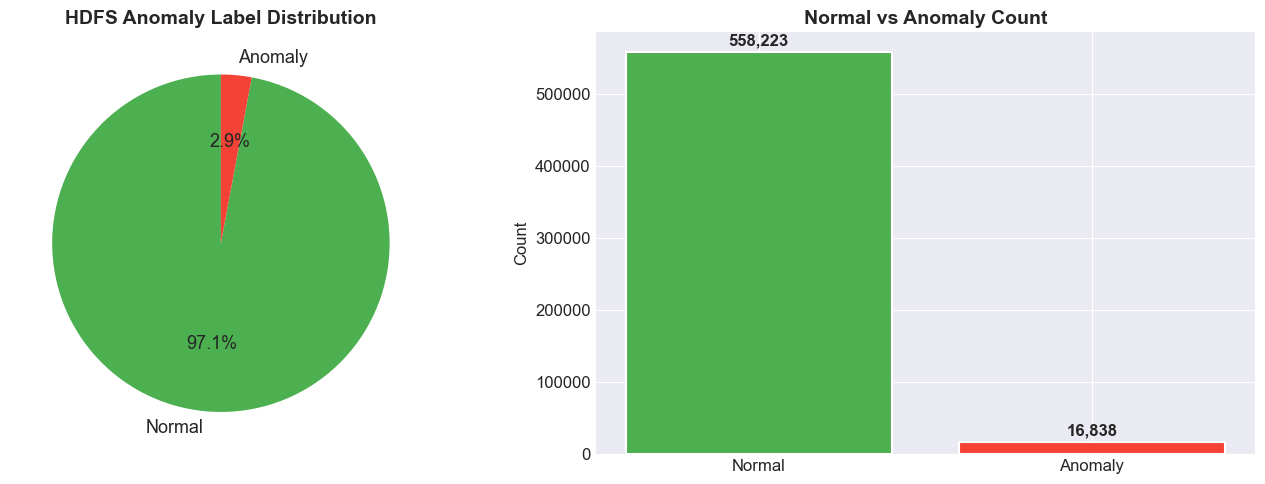

💾 Saved: results/figures/01_hdfs_anomaly_distribution.png


In [17]:
# === Anomaly Distribution Pie Chart ===
if label_files and 'label_df' in dir():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    label_col = label_df.columns[-1]
    counts = label_df[label_col].value_counts()
    
    # Pie chart
    pie_colors_anomaly = ['#4CAF50', '#F44336']
    ax1.pie(counts.values, labels=counts.index, colors=pie_colors_anomaly,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
    ax1.set_title('HDFS Anomaly Label Distribution', fontsize=14, fontweight='bold')
    
    # Bar chart
    bars = ax2.bar(counts.index.astype(str), counts.values, color=pie_colors_anomaly, 
                   edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_title('Normal vs Anomaly Count', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '01_hdfs_anomaly_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Saved: results/figures/01_hdfs_anomaly_distribution.png")

## 1.9 — Summary & Next Steps

### ✅ What we accomplished:
- Downloaded 3 log datasets (HDFS_v1, BGL, OpenStack)
- Explored file structures and log formats
- Analyzed log level distributions
- Examined HDFS anomaly labels

### 📌 Key Findings:
| Aspect | HDFS | BGL | OpenStack |
|--------|------|-----|----------|
| Labels | ✅ block-level anomaly | ✅ alert labels | ✅ available |
| Use Case | Distributed file system | Supercomputer | Cloud platform |
| Primary Focus | Session-based anomaly | Event-based anomaly | Service failures |
